# FaIR Climate Model Simulations with Extended Emissions Scenarios

This notebook runs the FaIR v2.2 climate model with extended emissions scenarios (1750-2501)
to generate climate projections. It processes emissions through CO2-equivalent calculations,
applies blending for smooth transitions, and produces temperature and concentration projections
across seven scenarios ranging from very low (VL) to very high (HL) emissions.

In [1]:
import os

import matplotlib.patheffects as pe
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import pooch
from fair import FAIR
from fair.interface import initialise
from fair.io import read_properties

/Users/bensan/ScenarioMIP_final/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
f = FAIR()
memory_limited = False

In [3]:
snames = ["VL", "LN", "L", "ML", "M", "H", "HL"]
snames_short = ["VL", "LN", "L", "ML", "M", "H", "HL"]
sname21_short = ["VL", "LN", "L", "ML", "M", "H", "HL"]

f.define_time(1750, 2501, 1)
f.define_scenarios(snames)
species, properties = read_properties("../data/fair-inputs/species_configs_properties_1.4.1.csv")
f.define_species(species, properties)
f.ch4_method = "Thornhill2021"

'memory_limited' is for testing, runs only 5 ensemble members.

If running full AR6 ensemble, need to
- set 'memory_limited' to False
- config file will be pulled from zenodo


In [4]:
if ~memory_limited:
    # Define the Zenodo record DOI and the specific file you want
    ZENODO_DOI = "10.5281/zenodo.7112539"  # Replace with your Zenodo DOI
    FILE_NAME = "calibrated_constrained_parameters.csv"  # Replace with your file name on Zenodo
    FILE_HASH = "md5:8a70a3fb05d0e0cf35e136de382582a5"  # Replace with the actual SHA256 hash of your file

    # Create a Pooch instance
    data_pooch = pooch.create(
        path="../data/fair-inputs",  # Local cache directory
        base_url=f"doi:{ZENODO_DOI}",  # Zenodo DOI as base URL
        version="1.5.0",
        registry={FILE_NAME: FILE_HASH},
    )

    # Fetch the file
    local_file_path = data_pooch.fetch(FILE_NAME)

    print(f"Config file downloaded to: {local_file_path}")

Config file downloaded to: /Users/bensan/ScenarioMIP_final/data/fair-inputs/1.5.0/calibrated_constrained_parameters.csv


/var/folders/pd/218my53900s1gy0k6lcyvjxm0000gn/T/ipykernel_36847/4288525121.py:1: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  if ~memory_limited:


In [5]:
if memory_limited:
    df_configs_short = pd.read_csv("../data/fair-inputs/1.5.0/calibrated_constrained_parameters_short.csv")
    f.define_configs(df_configs_short.index)
else:
    df_configs = pd.read_csv("../data/fair-inputs/1.5.0/calibrated_constrained_parameters.csv", index_col=0)
    f.define_configs(df_configs.index)

In [6]:
f.allocate()

In [7]:
scens = f.emissions.scenario.values

In [8]:
ldict = {}
ldict21 = {}
for i, s in enumerate(snames):
    ldict[s] = snames_short[i]
    ldict21[s] = sname21_short[i]

In [9]:
colors = {
    snames[6]: "#E744F6",  # HL
    snames[5]: "#a41212",  # H
    snames[4]: "#fc7b03",  # M
    snames[3]: "#dec820",  # ML
    snames[2]: "#20A359",  # L
    snames[1]: "#22e5db",  # LN
    snames[0]: "#16188F",  # VL
}

In [10]:
os.makedirs("../plots", exist_ok=True)

../data/fair-inputs/emissions_1750-2500.csv
is generated from 0503_extension_functioality_as_notebook.py

In [11]:
df_emis = pd.read_csv("../data/fair-inputs/emissions_1750-2500.csv")
df_emis.head()

,model,long_scenario,region,variable,unit,scenario,1750.5,1751.5,1752.5,1753.5,...,2491.5,2492.5,2493.5,2494.5,2495.5,2496.5,2497.5,2498.5,2499.5,2500.5
0,REMIND-MAgPIE 3.5-4.11,SSP1 - Very Low Emissions,World,BC,Mt BC/yr,VL,2.081488,2.083182,2.101828,2.102592,...,1.339155e+00,1.339155e+00,1.339155e+00,1.339155e+00,1.339155e+00,1.339154e+00,1.339154e+00,1.339154e+00,1.339154e+00,1.339154e+00
1,REMIND-MAgPIE 3.5-4.11,SSP1 - Very Low Emissions,World,C2F6,kt C2F6/yr,VL,0.000000,0.000000,0.000000,0.000000,...,1.184367e-08,1.126605e-08,1.071660e-08,1.019394e-08,9.696777e-09,9.223860e-09,8.774007e-09,8.346093e-09,7.939050e-09,7.551858e-09
2,REMIND-MAgPIE 3.5-4.11,SSP1 - Very Low Emissions,World,C3F8,kt C3F8/yr,VL,0.000000,0.000000,0.000000,0.000000,...,3.512270e-09,3.340975e-09,3.178034e-09,3.023039e-09,2.875604e-09,2.735359e-09,2.601954e-09,2.475055e-09,2.354345e-09,2.239522e-09
3,REMIND-MAgPIE 3.5-4.11,SSP1 - Very Low Emissions,World,C4F10,kt C4F10/yr,VL,0.000000,0.000000,0.000000,0.000000,...,4.947446e-10,4.706156e-10,4.476634e-10,4.258306e-10,4.050626e-10,3.853075e-10,3.665158e-10,3.486406e-10,3.316372e-10,3.154631e-10
4,REMIND-MAgPIE 3.5-4.11,SSP1 - Very Low Emissions,World,C5F12,kt C5F12/yr,VL,0.000000,0.000000,0.000000,0.000000,...,2.989456e-10,2.843658e-10,2.704971e-10,2.573048e-10,2.447559e-10,2.328190e-10,2.214643e-10,2.106634e-10,2.003892e-10,1.906161e-10


## Setup and Configuration

**Scenarios**: Seven emissions scenarios (VL, LN, L, ML, M, H, HL) representing very low
to very high emissions pathways
**Time range**: 1750-2501 (752 years)
**Species**: CO2 (FFI & AFOLU), CH4, N2O, plus 37 other GHGs and aerosols
**FaIR configuration**: Using calibrated parameters from Smith et al. with legacy CH4 lifetime method

In [12]:
gwpmat = pd.read_csv("../data/fair-inputs/gwp_mass_adjusted_100y.csv", index_col=0)

In [13]:
f.fill_from_csv(
    forcing_file="../data/fair-inputs/volcanic_solar.csv",
    emissions_file="../data/fair-inputs/emissions_1750-2500.csv",
)

In [14]:
gwp_nonco2 = gwpmat.copy()
gwp_nonco2.loc["CO2 AFOLU"] = np.nan
gwp_nonco2.loc["CO2 FFI"] = np.nan

In [15]:
nonco2 = f.emissions.sel(specie="CO2 FFI")[:, :, 0].copy()
for specie in f.emissions.specie.values:
    try:
        gwp = gwp_nonco2[specie]
    except KeyError:
        gwp = np.nan
    if ~np.isnan(gwp):
        nonco2 = nonco2 + f.emissions.sel(specie=specie)[:, :, 0] * gwp
    else:
        0

In [16]:
ncflr = np.ones(len(scens))
for i in range(len(scens)):
    ncflr[i] = nonco2.sel(scenario=scens[i])[-1] / 1e6
ncflr

array([0., 0., 0., 0., 0., 0., 0.])

In [17]:
scens_shrt = [ldict[s] for s in scens]

## CO2-Equivalent Emissions Calculation

Convert all GHG emissions to CO2-equivalents using 100-year Global Warming Potentials (GWP100).
This aggregates the climate forcing from all greenhouse gases into a single metric for
comparison across scenarios.

**Method**: Multiply each species' emissions by its GWP (e.g., CH4 = 29.8, N2O = 273) and sum to get total CO2e.


- Solar forcing set to zero (natural forcing handled separately by FaIR)

In [18]:
for s in f.scenarios:
    f.forcing.loc[dict(scenario=s, specie="Solar")] = 0

Plot emissions before running

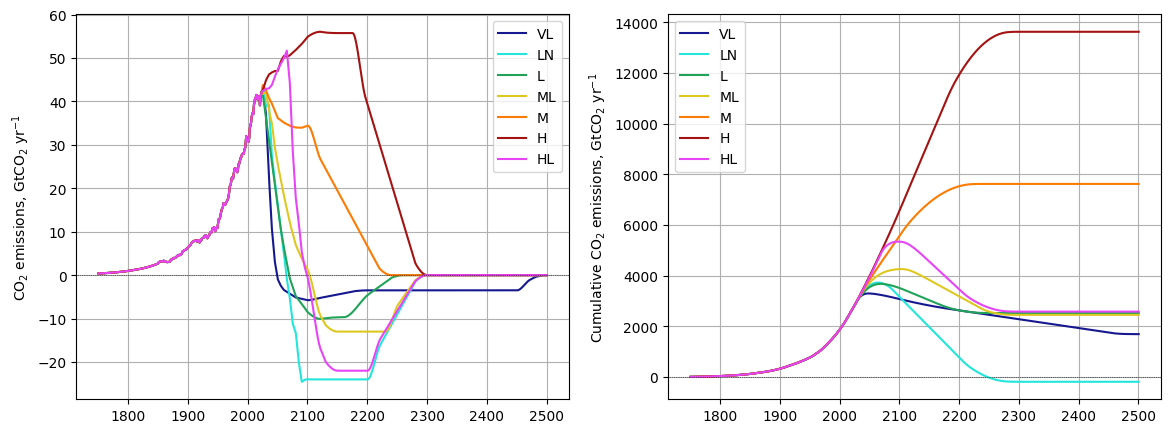

In [19]:
fig, ax = pl.subplots(nrows=1, ncols=2, figsize=(14, 5))
for scenario in f.scenarios:
    ax[0].plot(
        f.timepoints,
        (
            f.emissions.sel(scenario=scenario, specie="CO2 FFI", config=f.configs[0])
            + f.emissions.sel(scenario=scenario, specie="CO2 AFOLU", config=f.configs[0])
        ),
        label=scenario,
        color=colors[scenario],
    )
ax[0].set_ylabel("CO$_2$ emissions, GtCO$_2$ yr$^{-1}$")
ax[0].axhline(ls=":", color="k", lw=0.5)
ax[0].legend()
ax[0].grid()
for scenario in f.scenarios:
    ax[1].plot(
        f.timepoints,
        (
            f.emissions.sel(scenario=scenario, specie="CO2 FFI", config=f.configs[0])
            + f.emissions.sel(scenario=scenario, specie="CO2 AFOLU", config=f.configs[0])
        ).cumsum(),
        label=scenario,
        color=colors[scenario],
    )
ax[1].set_ylabel("Cumulative CO$_2$ emissions, GtCO$_2$ yr$^{-1}$")
ax[1].axhline(ls=":", color="k", lw=0.5)
ax[1].legend()
ax[1].grid()
pl.savefig("../plots/co2_emissions.png")

In [20]:
scens_out = []
for s in scens:
    df_scen = f.emissions.sel(scenario=s, config=df_configs.index[0]).to_pandas().T
    df_scen.insert(loc=0, column="Scenario", value=s)
    df_scen.dropna(inplace=True)
    scens_out.append(df_scen)
scens_out = pd.concat(scens_out)

Calculate CO2e

In [21]:
co2eo = f.emissions.sel(specie="CO2 FFI")[:, :, 0].copy() * 0
for specie in f.emissions.specie.values:
    try:
        gwp = gwpmat["ar6_gwp_mass_adjusted"][specie]

    except KeyError:
        gwp = np.nan
    if ~np.isnan(gwp):
        co2eo = co2eo + f.emissions.sel(specie=specie)[:, :, 0] * gwp / 1000000
    else:
        0
co2e = co2eo * 1e6  # -co2eo.loc[dict(timepoints=2019.5)].values+53.e6

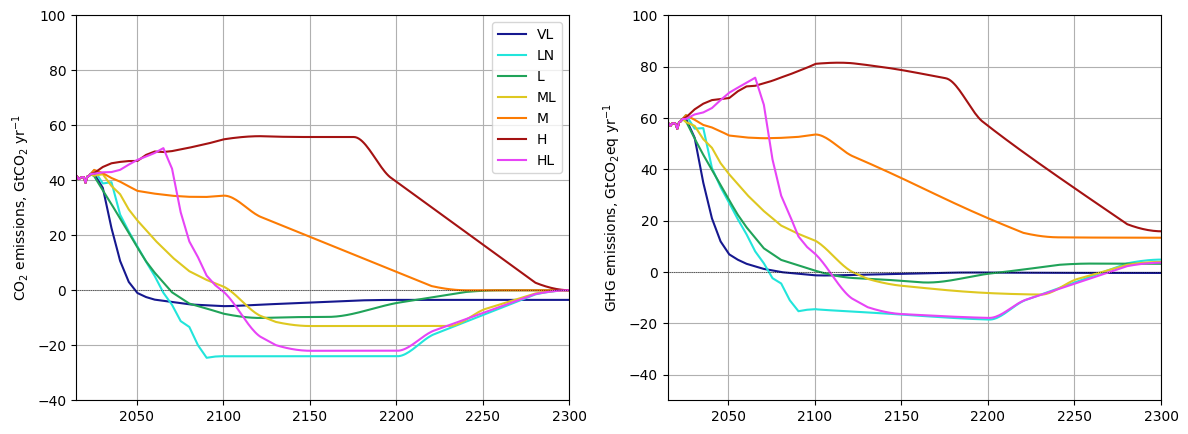

In [22]:
fig, ax = pl.subplots(1, 2, figsize=(14, 5))
for scenario in f.scenarios:
    ax[0].plot(
        f.timepoints,
        (
            f.emissions.sel(scenario=scenario, specie="CO2 FFI", config=f.configs[0])
            + f.emissions.sel(scenario=scenario, specie="CO2 AFOLU", config=f.configs[0])
        ),
        label=ldict21[scenario],
        color=colors[scenario],
    )
ax[0].set_ylabel("CO$_2$ emissions, GtCO$_2$ yr$^{-1}$")
ax[0].axhline(ls=":", color="k", lw=0.5)
ax[0].set_xlim(2015, 2300)
ax[0].set_ylim(-40, 100)

ax[0].legend()
ax[0].grid()

for scenario in f.scenarios:
    ax[1].plot(
        f.timepoints,
        co2e.sel(scenario=scenario) / 1e6,
        label=ldict21[scenario],
        color=colors[scenario],
    )
ax[1].set_ylabel("GHG emissions, GtCO$_2$eq yr$^{-1}$")
ax[1].axhline(ls=":", color="k", lw=0.5)
# ax[1].legend()
ax[1].set_xlim(2015, 2300)
ax[1].set_ylim(-50, 100)

ax[1].grid()
pl.savefig("../plots/ghg_emissions.png")

## Run FaIR

In [23]:
f.fill_species_configs("../data/fair-inputs/species_configs_properties_1.4.1.csv")
if memory_limited:
    f.override_defaults("../data/fair-inputs/1.5.0/calibrated_constrained_parameters_short.csv")
else:
    f.override_defaults("../data/fair-inputs/1.5.0/calibrated_constrained_parameters.csv")
initialise(f.concentration, f.species_configs["baseline_concentration"])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)
initialise(f.ocean_heat_content_change, 0)
f.run()

Running 5887 projections in parallel: 100%|██████████| 751/751 [01:11<00:00, 10.53timesteps/s]


## Results Visualization

Generate comprehensive plots showing:
1. **GHG emissions** (CO2e) trajectories with uncertainty bands (33rd-66th percentiles until 2100,
extended projections 2100-2150)
2. **Temperature anomalies** relative to 1850-1900 baseline with 5th-95th percentile ranges
3. **Multi-panel diagnostics**: CO2 emissions, cumulative CO2, CO2e, radiative forcing,
CO2 concentrations, and temperature
4. **Probability distributions**: Temperature outcomes at 2100, 2300, and peak warming across scenarios

In [24]:
# nohos=[x for x in f.scenarios if x != "high-overshoot"]
nohos = [x for x in f.scenarios]

In [25]:
f.timepoints[275]

np.float64(2025.5)

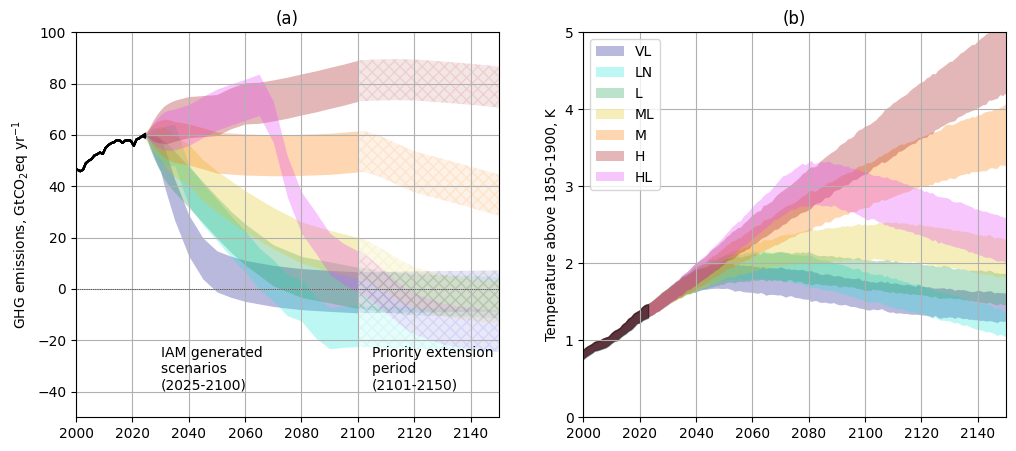

In [26]:
fig, ax = pl.subplots(1, 2, figsize=(12, 5))

unc = np.tanh((co2e.sel(scenario=nohos[0]) - co2e.sel(scenario=nohos[-2])) / 1e6 / 10) * 8
for scenario in nohos:
    ax[0].fill_between(
        f.timebounds[:351],
        co2e.sel(scenario=scenario)[:351] / 1e6 - unc[:351],
        co2e.sel(scenario=scenario)[:351] / 1e6 + unc[:351],
        color=colors[scenario],
        lw=0,
        alpha=0.3,
    )
    ax[0].fill_between(
        f.timepoints[350:],
        co2e.sel(scenario=scenario)[350:] / 1e6 - unc[350:],
        co2e.sel(scenario=scenario)[350:] / 1e6 + unc[350:],
        color=colors[scenario],
        hatch="XXX",
        lw=0,
        alpha=0.1,
    )
    ax[0].plot(
        f.timepoints[:275],
        co2e.sel(scenario=scenario)[:275] / 1e6,
        color="k",
    )
    # ax[0].plot(
    #     f.timepoints[350:],
    #     co2e.sel(scenario=scenario)[350:]/ 1e6,
    #     label=ldict21[scenario],
    #     color=colors[scenario],linestyle='--'
    # )
ax[0].text(2030, -39, "IAM generated \nscenarios \n(2025-2100)")
ax[0].text(2105, -39, "Priority extension\nperiod \n(2101-2150)")
ax[0].set_ylabel("GHG emissions, GtCO$_2$eq yr$^{-1}$")
ax[0].axhline(ls=":", color="k", lw=0.5)
# ax[1].legend()
ax[0].set_xlim(2000, 2150)
ax[0].set_ylim(-50, 100)

ax[0].grid()
ax[0].set_title("(a)")

for i, scenario in enumerate(nohos):
    ax[1].fill_between(
        f.timebounds[:],
        (
            f.temperature.sel(scenario=scenario, layer=0)[:]
            - f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850, 1902)).mean(dim="timebounds")
        ).quantile(0.33, dim="config"),
        (
            f.temperature.sel(scenario=scenario, layer=0)[:]
            - f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850, 1902)).mean(dim="timebounds")
        ).quantile(0.66, dim="config"),
        color=colors[scenario],
        lw=0,
        alpha=0.3,
        label=snames_short[i],
    )
    # ax[1].fill_between(
    #     f.timebounds[350:],
    #     (
    #         f.temperature.sel(scenario=scenario, layer=0)[350:]
    #         - f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850, 1902)).mean(dim="timebounds")
    #     ).quantile(0.33, dim="config"),
    #     (
    #         f.temperature.sel(scenario=scenario, layer=0)[350:]
    #         - f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850, 1902)).mean(dim="timebounds")
    #     ).quantile(0.66, dim="config"),
    #     color=colors[scenario],
    #     hatch="XXX",
    #     lw=0,
    #     alpha=0.1,
    # )
ax[1].fill_between(
    f.timebounds[:274],
    (
        f.temperature.sel(scenario=scenario, layer=0)[:274]
        - f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850, 1902)).mean(dim="timebounds")
    ).quantile(0.33, dim="config"),
    (
        f.temperature.sel(scenario=scenario, layer=0)[:274]
        - f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850, 1902)).mean(dim="timebounds")
    ).quantile(0.66, dim="config"),
    color="k",
    alpha=0.5,
)
ax[1].axhline(0, ls=":", color="k", lw=0.5)
ax[1].set_ylabel("Temperature above 1850-1900, K")
ax[1].set_ylim(0, 5)
ax[1].set_xlim(2000, 2150)

ax[1].grid()
ax[1].legend()

ax[1].set_title("(b)")
pl.savefig("../plots/temperature_emis.png", dpi=600, bbox_inches='tight')
pl.savefig("../plots/temperature_emis.pdf", format='pdf', bbox_inches='tight')

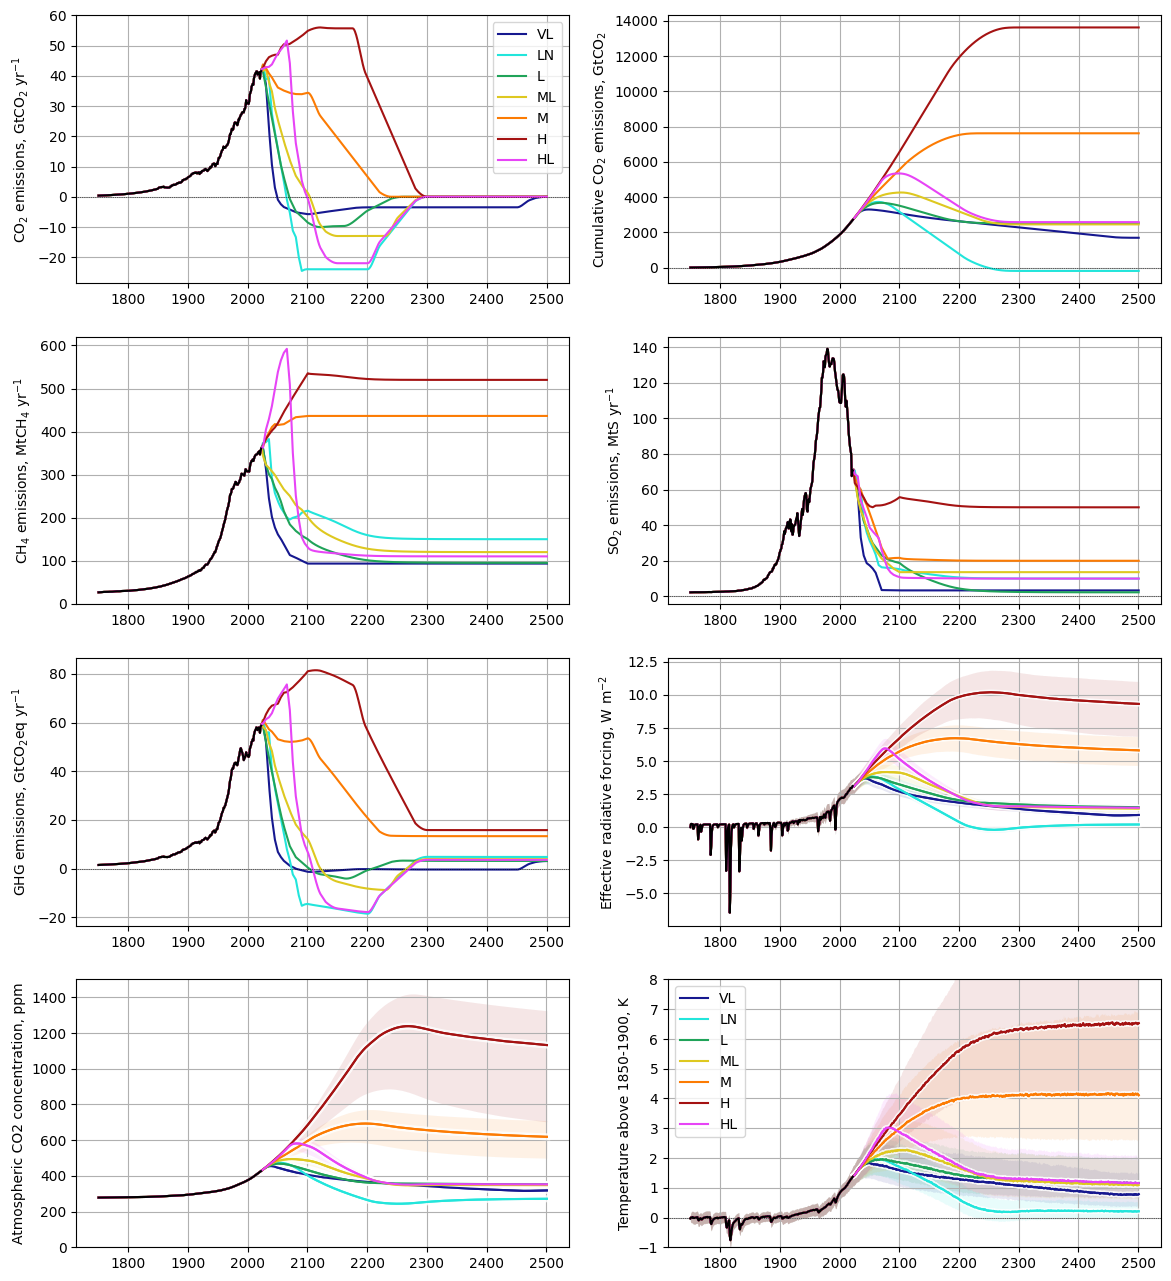

In [27]:
fig, ax = pl.subplots(nrows=4, ncols=2, figsize=(14, 16))
ax = ax.flatten()
for scenario in f.scenarios:
    ax[0].plot(
        f.timepoints,
        (
            f.emissions.sel(scenario=scenario, specie="CO2 FFI", config=f.configs[0])
            + f.emissions.sel(scenario=scenario, specie="CO2 AFOLU", config=f.configs[0])
        ),
        label=ldict[scenario],
        color=colors[scenario],
    )
# Add black historical line for CO2 emissions
ax[0].plot(
    f.timepoints[0:273],
    (
        f.emissions.sel(scenario=scenario, specie="CO2 FFI", config=f.configs[0])[0:273]
        + f.emissions.sel(scenario=scenario, specie="CO2 AFOLU", config=f.configs[0])[0:273]
    ),
    color="k",
)
ax[0].set_ylabel("CO$_2$ emissions, GtCO$_2$ yr$^{-1}$")
ax[0].axhline(ls=":", color="k", lw=0.5)
ax[0].legend()
ax[0].grid()

for scenario in f.scenarios:
    ax[1].plot(
        f.timepoints,
        (
            f.emissions.sel(scenario=scenario, specie="CO2 FFI", config=f.configs[0])
            + f.emissions.sel(scenario=scenario, specie="CO2 AFOLU", config=f.configs[0])
        ).cumsum(),
        label=scenario,
        color=colors[scenario],
    )
# Add black historical line for cumulative CO2 emissions
ax[1].plot(
    f.timepoints[0:273],
    (
        f.emissions.sel(scenario=scenario, specie="CO2 FFI", config=f.configs[0])
        + f.emissions.sel(scenario=scenario, specie="CO2 AFOLU", config=f.configs[0])
    ).cumsum()[0:273],
    color="k",
)
ax[1].set_ylabel("Cumulative CO$_2$ emissions, GtCO$_2$")
ax[1].axhline(ls=":", color="k", lw=0.5)
# ax[1].legend()
ax[1].grid()

for scenario in f.scenarios:
    ax[2].plot(
        f.timepoints,
        f.emissions.sel(scenario=scenario, specie="CH4", config=f.configs[0]),
        label=scenario,
        color=colors[scenario],
    )
# Add black historical line for CH4 emissions
ax[2].plot(
    f.timepoints[0:273],
    f.emissions.sel(scenario=scenario, specie="CH4", config=f.configs[0])[0:273],
    color="k",
)
ax[2].set_ylabel("CH$_4$ emissions, MtCH$_4$ yr$^{-1}$")
ax[2].axhline(ls=":", color="k", lw=0.5)
# ax[2].legend()
ax[2].grid()

for scenario in f.scenarios:
    ax[3].plot(
        f.timepoints,
        f.emissions.sel(scenario=scenario, specie="Sulfur", config=f.configs[0]),
        label=scenario,
        color=colors[scenario],
    )
# Add black historical line for sulfate emissions
ax[3].plot(
    f.timepoints[0:273],
    f.emissions.sel(scenario=scenario, specie="Sulfur", config=f.configs[0])[0:273],
    color="k",
)
ax[3].set_ylabel("SO$_2$ emissions, MtS yr$^{-1}$")
ax[3].axhline(ls=":", color="k", lw=0.5)
# ax[3].legend()
ax[3].grid()

for scenario in f.scenarios:
    ax[4].plot(
        f.timepoints,
        co2e.sel(scenario=scenario) / 1e6,
        label=scenario,
        color=colors[scenario],
    )
# Add black historical line for GHG emissions
ax[4].plot(
    f.timepoints[0:273],
    co2e.sel(scenario=scenario)[0:273] / 1e6,
    color="k",
)
ax[4].set_ylabel("GHG emissions, GtCO$_2$eq yr$^{-1}$")
ax[4].axhline(ls=":", color="k", lw=0.5)
# ax[4].legend()
ax[4].grid()

for scenario in f.scenarios:
    ax[5].fill_between(
        f.timebounds,
        f.forcing_sum.sel(scenario=scenario).quantile(0.05, dim="config"),
        f.forcing_sum.sel(scenario=scenario).quantile(0.95, dim="config"),
        color=colors[scenario],
        lw=0,
        alpha=0.1,
    )
    ax[5].plot(
        f.timebounds[274:],
        f.forcing_sum.sel(scenario=scenario).median(dim="config")[274:],
        path_effects=[pe.Stroke(linewidth=4, foreground="w", alpha=0.8), pe.Normal()],
        color=colors[scenario],
    )
for scenario in f.scenarios:
    ax[5].plot(
        f.timebounds,
        f.forcing_sum.sel(scenario=scenario).median(dim="config"),
        label=scenario,
        color=colors[scenario],
    )
# Add black historical line for radiative forcing
ax[5].plot(
    f.timebounds[0:273],
    f.forcing_sum.sel(scenario=scenario).median(dim="config")[0:273],
    color="k",
)
ax[5].set_ylabel("Effective radiative forcing, W m$^{-2}$")
# pl.legend();
ax[5].grid()

for scenario in f.scenarios:
    ax[6].fill_between(
        f.timebounds,
        (
            f.concentration.sel(specie="CO2").sel(
                scenario=scenario,
            )
        ).quantile(0.05, dim="config"),
        (f.concentration.sel(specie="CO2").sel(scenario=scenario)).quantile(0.95, dim="config"),
        color=colors[scenario],
        lw=0,
        alpha=0.1,
    )
    ax[6].plot(
        f.timebounds[274:],
        (f.concentration.sel(specie="CO2").sel(scenario=scenario)).median(dim="config")[274:],
        label=scenario,
        path_effects=[pe.Stroke(linewidth=5, foreground="w", alpha=0.8), pe.Normal()],
        color=colors[scenario],
    )
for scenario in f.scenarios:
    ax[6].plot(
        f.timebounds,
        (f.concentration.sel(specie="CO2").sel(scenario=scenario)).median(dim="config"),
        label=scenario,
        color=colors[scenario],
    )
# Add black historical line for CO2 concentration
ax[6].plot(
    f.timebounds[0:273],
    (f.concentration.sel(specie="CO2").sel(scenario=scenario)).median(dim="config")[0:273],
    color="k",
)
ax[6].axhline(0, ls=":", color="k", lw=0.5)
ax[6].set_ylabel("Atmospheric CO2 concentration, ppm")
ax[6].set_ylim(0, 1500)
ax[6].grid()

for scenario in f.scenarios:
    ax[7].fill_between(
        f.timebounds,
        (
            f.temperature.sel(scenario=scenario, layer=0)
            - f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850, 1902)).mean(dim="timebounds")
        ).quantile(0.05, dim="config"),
        (
            f.temperature.sel(scenario=scenario, layer=0)
            - f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850, 1902)).mean(dim="timebounds")
        ).quantile(0.95, dim="config"),
        color=colors[scenario],
        lw=0,
        alpha=0.1,
    )
    ax[7].plot(
        f.timebounds[274:],
        (
            f.temperature.sel(scenario=scenario, layer=0)[274:]
            - f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850, 1902)).mean(dim="timebounds")
        ).median(dim="config"),
        path_effects=[pe.Stroke(linewidth=4, foreground="w", alpha=0.8), pe.Normal()],
        color=colors[scenario],
    )
for scenario in f.scenarios:
    ax[7].plot(
        f.timebounds,
        (
            f.temperature.sel(scenario=scenario, layer=0)
            - f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850, 1902)).mean(dim="timebounds")
        ).median(dim="config"),
        label=ldict[scenario],
        color=colors[scenario],
    )
ax[7].plot(
    f.timebounds[0:273],
    (
        f.temperature.sel(scenario=scenario, layer=0)[0:273]
        - f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850, 1902)).mean(dim="timebounds")
    ).median(dim="config"),
    color="k",
)
ax[7].axhline(0, ls=":", color="k", lw=0.5)
ax[7].set_ylabel("Temperature above 1850-1900, K")
ax[7].set_ylim(-1, 8)
ax[7].legend()

ax[7].grid()

pl.savefig("../plots/extensions.png", dpi=600, bbox_inches='tight')
pl.savefig("../plots/extensions.pdf", format='pdf', bbox_inches='tight')

In [32]:
f21c = scens

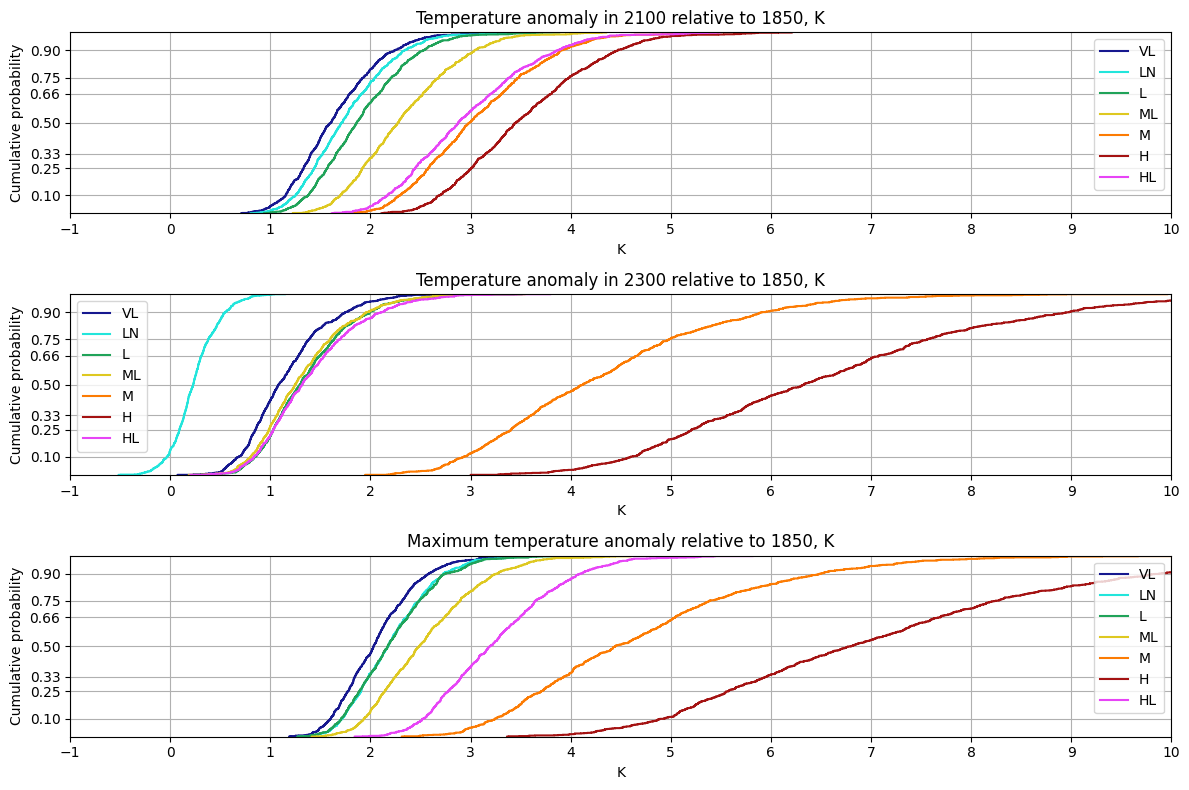

In [33]:
fig, ax = pl.subplots(3, 1, figsize=(12, 8))
ax = ax.flatten()

for scenario in f21c:
    a = ax[0].ecdf(
        f.temperature.sel(scenario=scenario, layer=0, timebounds=2100)
        - f.temperature.sel(scenario=scenario, layer=0, timebounds=1850),
        color=colors[scenario],
        label=ldict21[scenario],
    )
ax[0].set_title("Temperature anomaly in 2100 relative to 1850, K")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Cumulative probability")
ax[0].set_yticks([0.1, 0.25, 0.33, 0.5, 0.66, 0.75, 0.9])
ax[0].set_xticks(np.array([-0.5, 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]) * 2)
ax[0].set_xlim([-1, 10])
ax[0].legend()
ax[0].grid()


for scenario in f21c:
    a = ax[1].ecdf(
        f.temperature.sel(scenario=scenario, layer=0, timebounds=2300)
        - f.temperature.sel(scenario=scenario, layer=0, timebounds=1850),
        color=colors[scenario],
        label=ldict21[scenario],
    )
ax[1].set_title("Temperature anomaly in 2300 relative to 1850, K")
ax[1].set_ylabel("Cumulative probability")
ax[1].set_xlabel("K")

ax[1].set_yticks([0.1, 0.25, 0.33, 0.5, 0.66, 0.75, 0.9])
ax[1].set_xticks(np.array([-0.5, 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]) * 2)
ax[1].set_xlim([-1, 10])
ax[1].legend()
ax[1].grid()


for scenario in f21c:
    a = ax[2].ecdf(
        f.temperature.sel(scenario=scenario, layer=0).max(dim="timebounds")
        - f.temperature.sel(scenario=scenario, layer=0, timebounds=1850),
        color=colors[scenario],
        label=ldict21[scenario],
    )
ax[2].set_title("Maximum temperature anomaly relative to 1850, K")
ax[2].set_xlabel("K")
ax[2].set_ylabel("Cumulative probability")
ax[2].set_yticks([0.1, 0.25, 0.33, 0.5, 0.66, 0.75, 0.9])
ax[2].set_xticks(np.array([-0.5, 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]) * 2)
ax[2].set_xlim([-1, 10])
ax[2].legend(loc="upper right")
ax[2].grid()
pl.tight_layout()